# 3D Segmentation with UNETR++ and the Datamint Trainer API

This notebook shows how to train a **UNETR++** volumetric segmentation model on the **Synapse Multi-Organ CT** (https://www.kaggle.com/datasets/dogcdt/synapse) dataset using Datamint's **Trainer API**.

## What is UNETR++?

UNETR++ (Shaker et al., 2024) is a **true 3D** segmentation model, it takes full volumetric inputs `(B, C, D, H, W)` and outputs 3D segmentation maps, unlike slice-based approaches that process 2D cuts independently.

The architecture:
- **Encoder**: 4-stage hierarchical transformer with **Efficient Paired Attention (EPA)**, decomposes attention into a *channel branch* and a *spatial branch* to keep complexity sub-quadratic
- **Decoder**: 4 transposed-conv blocks with element-wise skip connections; the final block uses a ResBlock (not a transformer) since full-resolution attention is too expensive

> Shaker et al., "UNETR++: Delving into Efficient and Accurate 3D Medical Image Segmentation", IEEE TMI 2024

## What You'll Learn

1. Download and preprocess the Synapse Multi-Organ CT dataset
2. Upload 3D volumes and segmentation masks to Datamint
3. Train with `UNETRPPTrainer` using a demo-friendly config
4. Visualise 3D predictions on axial slices

## Required Dependencies

```bash
pip install datamint gdown nibabel h5py
```

## ⚠️ Dataset Access

The Synapse dataset can be found at Kaggle.

In [12]:
%pip install -q datamint gdown nibabel h5py

Note: you may need to restart the kernel to use updated packages.


In [1]:
from datamint import Api

PROJECT_NAME = "UNETRPP_Synapse_Tutorial"
api = Api()

/home/luan/Desktop/Datamint/Codes/datamint-python-api/datamint/env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Setup: Create Project

In [2]:
proj = api.projects.create(
    name=PROJECT_NAME,
    description="UNETR++ tutorial on Synapse Multi-Organ CT",
    exists_ok=True,
)
proj

UNETRPP_Synapse_Tutorial
2026-06-03T11:44:21.178Z
luandalmazo@gmail.com
False
12
UNETR++ tutorial on Synapse Multi-Organ CT


## 2. Dataset Preparation: Download Synapse

**Label map** (8 abdominal organs):

| Value | Organ |
|---|---|
| 1 | Aorta |
| 2 | Gallbladder |
| 3 | Spleen |
| 4 | Left Kidney |
| 5 | Right Kidney |
| 6 | Liver |
| 7 | Stomach |
| 8 | Pancreas |


> Download the dataset from Kaggle:

In [15]:
!curl -L -o /tmp/synapse.zip https://www.kaggle.com/api/v1/datasets/download/dogcdt/synapse

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  607M  100  607M    0     0  24.3M      0  0:00:24  0:00:24 --:--:-- 22.1M


Unzip the dataset:

In [16]:
!unzip /tmp/synapse.zip -d /tmp/

Archive:  /tmp/synapse.zip
  inflating: /tmp/Synapse/test_vol_h5/case0001.npy.h5  
  inflating: /tmp/Synapse/test_vol_h5/case0002.npy.h5  
  inflating: /tmp/Synapse/test_vol_h5/case0003.npy.h5  
  inflating: /tmp/Synapse/test_vol_h5/case0004.npy.h5  
  inflating: /tmp/Synapse/test_vol_h5/case0008.npy.h5  
  inflating: /tmp/Synapse/test_vol_h5/case0022.npy.h5  
  inflating: /tmp/Synapse/test_vol_h5/case0025.npy.h5  
  inflating: /tmp/Synapse/test_vol_h5/case0029.npy.h5  
  inflating: /tmp/Synapse/test_vol_h5/case0032.npy.h5  
  inflating: /tmp/Synapse/test_vol_h5/case0035.npy.h5  
  inflating: /tmp/Synapse/test_vol_h5/case0036.npy.h5  
  inflating: /tmp/Synapse/test_vol_h5/case0038.npy.h5  
  inflating: /tmp/Synapse/train_npz/case0005_slice000.npz  
  inflating: /tmp/Synapse/train_npz/case0005_slice001.npz  
  inflating: /tmp/Synapse/train_npz/case0005_slice002.npz  
  inflating: /tmp/Synapse/train_npz/case0005_slice003.npz  
  inflating: /tmp/Synapse/train_npz/case0005_slice004.npz  
 

In [17]:
import gdown
from pathlib import Path

DATA_DIR = Path("/tmp/Synapse")
H5_DIR   = DATA_DIR / "test_vol_h5"

h5_files = sorted(H5_DIR.glob("*.npy.gz")) or sorted(H5_DIR.glob("*.h5"))
print(f"Found {len(h5_files)} volume files")

Found 12 volume files


### 2.1 Convert to NIfTI

Datamint accepts NIfTI (`.nii.gz`) for 3D volumes. We load each H5 file, extract the image and label arrays, and save them as NIfTI with `nibabel`.

The HDF5 files contain:
- `'image'` — float array `(H, W, D)` with HU values clipped to `[-125, 275]` and normalised to `[0, 1]`
- `'label'` — int array `(H, W, D)` with organ label values 0–8

In [ ]:
import h5py
import numpy as np
import nibabel as nib

NII_DIR   = DATA_DIR / 'nifti' / 'images'
LABEL_DIR = DATA_DIR / 'nifti' / 'labels'
NII_DIR.mkdir(parents=True, exist_ok=True)
LABEL_DIR.mkdir(parents=True, exist_ok=True)

nii_image_paths = []
nii_label_paths = []

for h5_path in h5_files:
    case_id = h5_path.stem.split('.')[0]  # 'case0001.h5' -> 'case0001'

    with h5py.File(h5_path, 'r') as f:
        image = f['image'][:]   # (H, W, D) float
        label = f['label'][:]   # (H, W, D) int

    # Downsample 512x512 -> 256x256 in-plane (test purposes)
    # Reduces sliding-window patch count by ~4x during validation.
    image = image[::2, ::2, :]  # nearest-neighbour for images (float)
    label = label[::2, ::2, :]  # nearest-neighbour for labels (int), preserves class ids

    img_nii = nib.Nifti1Image(image.astype(np.float32), affine=np.eye(4))
    lbl_nii = nib.Nifti1Image(label.astype(np.uint8),   affine=np.eye(4))

    img_path = NII_DIR   / f'{case_id}.nii.gz'
    lbl_path = LABEL_DIR / f'{case_id}_label.nii.gz'

    nib.save(img_nii, img_path)
    nib.save(lbl_nii, lbl_path)

    nii_image_paths.append(img_path)
    nii_label_paths.append(lbl_path)

print(f'Converted {len(nii_image_paths)} volumes, spatial size: {image.shape}')


## 3. Upload to Datamint

### 3.1 Upload CT Volumes

In [25]:
uploaded = api.resources.upload_resources(
    [str(p) for p in nii_image_paths],
    tags=['synapse', 'ct', 'abdomen'],
    publish_to=proj,
    progress_bar=True,
)
print(f"Uploaded {len(uploaded)} volumes")

Uploading resources: 100%|██████████| 12/12 [00:26<00:00,  2.23s/file, file=case0036.nii.gz]


Uploaded 12 volumes


### 3.2 Upload Segmentation Masks

Each label file contains integer values 0–8 (0 = background). `upload_volume_segmentation` maps each integer to its organ name.

In [29]:
from tqdm.auto import tqdm

SYNAPSE_CLASSES = {
    1: 'aorta',
    2: 'gallbladder',
    3: 'spleen',
    4: 'left_kidney',
    5: 'right_kidney',
    6: 'liver',
    7: 'stomach',
    8: 'pancreas',
}

all_resources = list(api.resources.get_list(project_name=PROJECT_NAME))
# r.filename is 'case0001.nii.gz'; strip the full extension to get 'case0001'
stem_to_resource = {r.filename.replace('.nii.gz', ''): r for r in all_resources}

for img_path, lbl_path in tqdm(zip(nii_image_paths, nii_label_paths), total=len(nii_image_paths)):
    case_id  = img_path.name.replace('.nii.gz', '')  # Path.stem gives 'case0001.nii', use .name instead
    resource = stem_to_resource[case_id]
    api.annotations.upload_volume_segmentation(
        resource=resource,
        file_path=str(lbl_path),
        name=SYNAPSE_CLASSES,
        imported_from='Synapse Multi-Organ CT',
    )

print('Segmentation masks uploaded!')


100%|██████████| 12/12 [01:53<00:00,  9.42s/it]

Segmentation masks uploaded!


### 3.3 Assign Train / Val / Test Splits

In [5]:
import random

all_resources = list(api.resources.get_list(project_name=PROJECT_NAME))
all_resources.sort(key=lambda r: r.filename)

random.seed(42)
random.shuffle(all_resources)

n = len(all_resources)
n_train = int(0.70 * n)
n_val   = int(0.15 * n)

api.projects.assign_splits(proj, all_resources[:n_train],        split_name='train')
api.projects.assign_splits(proj, all_resources[n_train:n_train + n_val], split_name='val')
api.projects.assign_splits(proj, all_resources[n_train + n_val:], split_name='test')

print(f"Train: {n_train}  Val: {n_val}  Test: {n - n_train - n_val}")

Train: 8  Val: 1  Test: 3


## 4. Train UNETR++

We use a **demo config** sized for ≥ 4 GB VRAM.

In [5]:
import os
os.environ['MLFLOW_ENABLE_ARTIFACTS_PROGRESS_BAR'] = 'false'

from datamint.lightning import UNETRPPTrainer

trainer = UNETRPPTrainer(
    project=PROJECT_NAME,
    patch_crop_size=(64, 64, 64),
    feature_size=16,
    num_heads=4,
    depths=[1, 1, 1, 1],
    in_channels=1,
    batch_size=1,
    max_epochs=3,
    sw_overlap=0.5,
    early_stopping_patience=1,
    accelerator='gpu',
)


In [ ]:
results = trainer.fit()

In [7]:
print("Test results:")
for metric_dict in results['test_results']:
    for k, v in metric_dict.items():
        print(f"  {k}: {v:.4f}")

Test results:
  test/loss: 1.5252
  test/dice: 0.0025
  test/iou: 0.0002


## 5. Visualise Predictions

We pick a test volume, run sliding-window inference, and display a few axial slices with the ground truth and predicted segmentation side by side.

Each colour corresponds to one organ class. The model's `validation_step` already uses sliding-window inference internally, here we call it directly for illustration.

Classes (8): ['aorta', 'gallbladder', 'left_kidney', 'liver', 'pancreas', 'right_kidney', 'spleen', 'stomach']


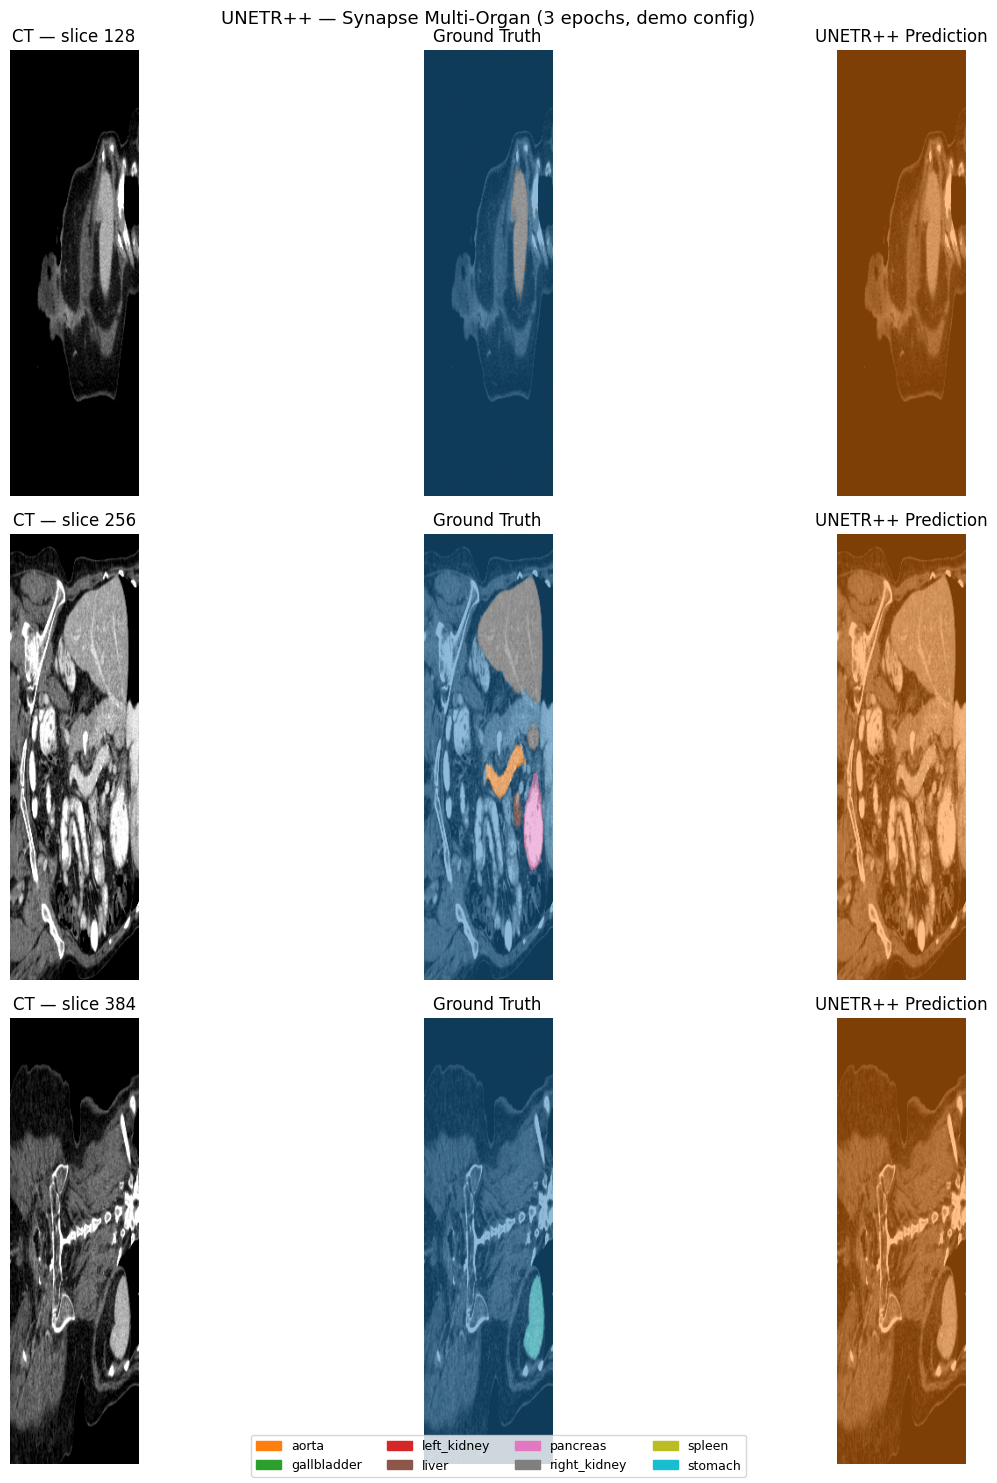

In [8]:
import torch
import numpy as np
import matplotlib.pyplot as plt

model = trainer.model
model.eval()

class_names = list(trainer.dataset.seglabel_list)
num_classes  = len(class_names)
print(f'Classes ({num_classes}): {class_names}')

test_ds = trainer.datamodule.test_dataloader().dataset
sample   = test_ds[0]

# Dataset returns numpy arrays: convert before calling model
image    = torch.from_numpy(np.ascontiguousarray(sample['image'])).float()     # (C, D, H, W)
gt_masks = torch.from_numpy(np.ascontiguousarray(sample['segmentations'])).float()  # (num_classes+1, D, H, W)

with torch.inference_mode():
    logits = model._sliding_window_inference(
        image.unsqueeze(0)  # (1, C, D, H, W)
    )

pred_masks = (logits[0] > 0).cpu()  # (num_classes, D, H, W)

# Collapse to label map: 0 = background, class index + 1 otherwise
gt_np   = gt_masks[1:].numpy()
pred_np = pred_masks.numpy()
gt_label_map   = (gt_np.argmax(axis=0) + 1) * gt_np.any(axis=0)
pred_label_map = (pred_np.argmax(axis=0) + 1) * pred_np.any(axis=0)

# ---- Plot 3 axial slices ----
CMAP = plt.get_cmap('tab10', num_classes + 1)
D = image.shape[1]
slice_indices = [D // 4, D // 2, 3 * D // 4]

fig, axes = plt.subplots(len(slice_indices), 3, figsize=(15, 5 * len(slice_indices)))

for row, s in enumerate(slice_indices):
    ct = image[0, s].numpy()

    axes[row, 0].imshow(ct, cmap='gray')
    axes[row, 0].set_title(f'CT — slice {s}')
    axes[row, 0].axis('off')

    axes[row, 1].imshow(ct, cmap='gray')
    axes[row, 1].imshow(gt_label_map[s], cmap=CMAP, alpha=0.5, vmin=0, vmax=num_classes)
    axes[row, 1].set_title('Ground Truth')
    axes[row, 1].axis('off')

    axes[row, 2].imshow(ct, cmap='gray')
    axes[row, 2].imshow(pred_label_map[s], cmap=CMAP, alpha=0.5, vmin=0, vmax=num_classes)
    axes[row, 2].set_title('UNETR++ Prediction')
    axes[row, 2].axis('off')

handles = [plt.Rectangle((0,0),1,1, color=CMAP(i+1)) for i in range(num_classes)]
fig.legend(handles, class_names, loc='lower center', ncol=4, fontsize=9)
plt.suptitle('UNETR++ — Synapse Multi-Organ (3 epochs, demo config)', fontsize=13)
plt.tight_layout()
plt.show()


## 6. Customisation Options

### 6.1 Production config (paper settings)

```python
trainer = UNETRPPTrainer(
      project=PROJECT_NAME,
      patch_crop_size=(64, 128, 128),
      feature_size=16,
      num_heads=4,
      depths=[3, 3, 3, 3],
      in_channels=1,
      batch_size=2,
      max_epochs=1000,
      sw_overlap=0.5, 
      num_workers=4,
      early_stopping_patience=50,
      accelerator='auto',
  )

```

### 6.2 Mixed precision (halves VRAM)

```python
trainer = UNETRPPTrainer(
    project=PROJECT_NAME,
    patch_crop_size=(128, 128, 128),
    trainer_kwargs={'precision': '16-mixed'},
)
```

### 6.3 Custom loss

```python
from monai.losses import DiceCELoss

trainer = UNETRPPTrainer(
    project=PROJECT_NAME,
    loss_fn=DiceCELoss(to_onehot_y=False, sigmoid=True),
)
```

### 6.4 Multi-channel MRI (e.g. BraTS)

```python
trainer = UNETRPPTrainer(
    project='BraTS_Project',
    in_channels=4,   # T1, T1ce, T2, FLAIR
    patch_crop_size=(128, 128, 128),
)
```

### 6.5 Sliding-window overlap at inference

Higher overlap reduces stitching artefacts at the cost of more compute. The default is `0.5`.

```python
trainer = UNETRPPTrainer(
    project=PROJECT_NAME,
    sw_overlap=0.75,   # more overlap → smoother predictions, ~4× slower
)
```

> **Note on convergence**: 3 epochs are enough to verify the pipeline works, but meaningful segmentation quality requires +800 epochs. 